In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Load data
df = pd.read_csv("sales_data.csv")
df.head()


,Order_ID,Order_Date,Customer_ID,Gender,Age,Region,Product_Category,Quantity,Price
0,1001,2024-01-05,C001,Male,25,West,Electronics,2,15000
1,1002,2024-01-07,C002,Female,32,North,Clothing,3,1200
2,1003,2024-01-10,C003,Female,45,South,Grocery,5,200
3,1004,2024-01-12,C004,Male,29,East,Electronics,1,22000
4,1005,2024-01-15,C005,Female,38,West,Clothing,4,1800


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order_ID          15 non-null     int64 
 1   Order_Date        15 non-null     object
 2   Customer_ID       15 non-null     object
 3   Gender            15 non-null     object
 4   Age               15 non-null     int64 
 5   Region            15 non-null     object
 6   Product_Category  15 non-null     object
 7   Quantity          15 non-null     int64 
 8   Price             15 non-null     int64 
dtypes: int64(4), object(5)
memory usage: 1.2+ KB


,Order_ID,Age,Quantity,Price
count,15.000000,15.000000,15.00000,15.000000
mean,1008.000000,34.333333,4.00000,7630.000000
std,4.472136,7.733662,2.77746,10267.618308
min,1001.000000,22.000000,1.00000,100.000000
25%,1004.500000,28.500000,2.00000,190.000000
50%,1008.000000,34.000000,3.00000,1700.000000
75%,1011.500000,39.000000,5.50000,16500.000000
max,1015.000000,50.000000,10.00000,30000.000000


In [6]:
df.isnull().sum()  #check null count

Order_ID            0
Order_Date          0
Customer_ID         0
Gender              0
Age                 0
Region              0
Product_Category    0
Quantity            0
Price               0
dtype: int64

In [7]:
df.duplicated().sum() # check duplicated


0

In [8]:
#Create Revenue Column
df["Revenue"] = df["Quantity"] * df["Price"]
df.head()

,Order_ID,Order_Date,Customer_ID,Gender,Age,Region,Product_Category,Quantity,Price,Revenue
0,1001,2024-01-05,C001,Male,25,West,Electronics,2,15000,30000
1,1002,2024-01-07,C002,Female,32,North,Clothing,3,1200,3600
2,1003,2024-01-10,C003,Female,45,South,Grocery,5,200,1000
3,1004,2024-01-12,C004,Male,29,East,Electronics,1,22000,22000
4,1005,2024-01-15,C005,Female,38,West,Clothing,4,1800,7200


In [9]:
#Total Revenue
total_revenue = df["Revenue"].sum()
total_revenue

173920

In [10]:
# Revenue by Region
region_sales = df.groupby("Region")["Revenue"].sum()
region_sales

Region
East     28000
North    43000
South    24760
West     78160
Name: Revenue, dtype: int64

In [12]:
#Revenue by Category
category_sales = df.groupby("Product_Category")["Revenue"].sum()
category_sales


Product_Category
Clothing        28800
Electronics    140000
Grocery          5120
Name: Revenue, dtype: int64

In [20]:
#Gender-wise Revenue
gender_sales = df.groupby("Gender")["Revenue"].sum()
gender_sales

Gender
Female    76520
Male      97400
Name: Revenue, dtype: int64

In [21]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [24]:
df["Month"] = df["Order_Date"].dt.month
df["1"] = df["Order_Date"].dt.month_name()


Monthly Revenue


In [23]:
monthly_sales = df.groupby("Month")["Revenue"].sum().reset_index()
monthly_sales


,Month,Revenue
0,1,63800
1,2,54860
2,3,55260


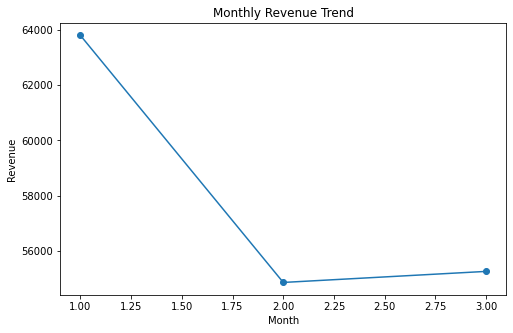

In [25]:
plt.figure(figsize=(8,5))
plt.plot(monthly_sales["Month"], monthly_sales["Revenue"], marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


Create Age Groups

In [26]:
bins = [20,30,40,50,60]
labels = ["20-30","30-40","40-50","50-60"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)
df.head()


,Order_ID,Order_Date,Customer_ID,Gender,Age,Region,Product_Category,Quantity,Price,Revenue,Month,Month_Name,1,Age_Group
0,1001,2024-01-05,C001,Male,25,West,Electronics,2,15000,30000,1,January,January,20-30
1,1002,2024-01-07,C002,Female,32,North,Clothing,3,1200,3600,1,January,January,30-40
2,1003,2024-01-10,C003,Female,45,South,Grocery,5,200,1000,1,January,January,40-50
3,1004,2024-01-12,C004,Male,29,East,Electronics,1,22000,22000,1,January,January,20-30
4,1005,2024-01-15,C005,Female,38,West,Clothing,4,1800,7200,1,January,January,30-40


Revenue by Age Group

In [27]:
age_sales = df.groupby("Age_Group")["Revenue"].sum().reset_index()
age_sales


,Age_Group,Revenue
0,20-30,83000
1,30-40,59020
2,40-50,31900
3,50-60,0


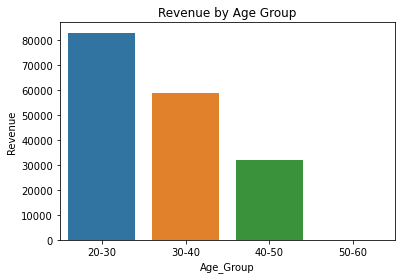

In [28]:
plt.figure(figsize=(6,4))
sns.barplot(x="Age_Group", y="Revenue", data=age_sales)
plt.title("Revenue by Age Group")
plt.show()


Revenue by Region

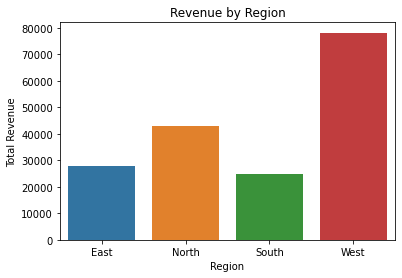

In [14]:
plt.figure(figsize=(6,4))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.show()


Revenue by Category

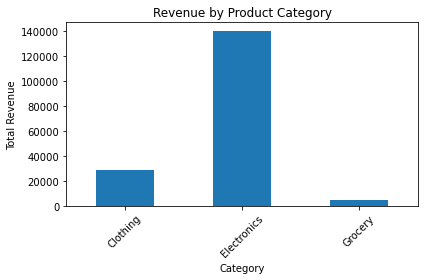

In [18]:
category_sales.plot(kind='bar', figsize=(6,4))
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# KPI Metrics

In [29]:
#Total Revenue
total_revenue = df["Revenue"].sum()


In [30]:
#Total Orders
total_orders = df["Order_ID"].nunique()


In [31]:
#Average Order Value
average_order_value = total_revenue / total_orders
average_order_value


11594.666666666666

In [32]:
#Total Quantity Sold
total_quantity = df["Quantity"].sum()


KPI Summary

In [33]:
print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", average_order_value)
print("Total Quantity Sold:", total_quantity)


Total Revenue: 173920
Total Orders: 15
Average Order Value: 11594.666666666666
Total Quantity Sold: 60


In [34]:
#Top Performing Category
df.groupby("Product_Category")["Revenue"].sum().sort_values(ascending=False)


Product_Category
Electronics    140000
Clothing        28800
Grocery          5120
Name: Revenue, dtype: int64

In [35]:
#Best Performing Region
df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)


Region
West     78160
North    43000
East     28000
South    24760
Name: Revenue, dtype: int64

# Key Insights:

Electronics is the highest revenue-generating category, contributing major share of total sales.

West region shows strongest performance among all regions.

Customers aged 30–40 drive most revenue.

Revenue shows consistent growth from January to March.

Average Order Value indicates strong purchase size per transaction.